In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering

In [2]:
iris = sns.load_dataset('iris')

X = iris.drop(columns=['species']).values
Y = iris['species'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pcaed = pca.fit_transform(X_scaled)

In [3]:
kmeans = KMeans(n_clusters=3, random_state=36, n_init=12)
labels_kmeans = kmeans.fit_predict(X_pcaed)

centroids = kmeans.cluster_centers_
inertia = kmeans.inertia_

print("KMeans Results")
print("Cluster Centers (Centroids):\n", centroids)
print("\nInertia:", inertia)
print("\nCluster Labels:\n", labels_kmeans)

KMeans Results
Cluster Centers (Centroids):
 [[ 1.72103664  0.60288719]
 [-2.22475316  0.28892745]
 [ 0.57262144 -0.80720888]]

Inertia: 115.02075663593986

Cluster Labels:
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 2 2 2 0 2 2 2 2 2 2 2 2 0 2 2 2 2 0 2 2 2
 2 0 0 0 2 2 2 2 2 2 2 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 0 0 0 0 0 0 2 2 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]


In [4]:
agglo = AgglomerativeClustering(n_clusters=3)
labels_agglo = agglo.fit_predict(X_pcaed)

print("\nAgglomerative Clustering Labels:\n", labels_agglo)


Agglomerative Clustering Labels:
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 1 1 1 2 1 1 1 1 1 1 1 1 2 1 1 1 1 2 1 1 1
 1 1 1 2 1 1 1 1 1 1 1 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 1 2 2 1 2 1 2 2
 1 2 1 1 2 2 2 2 1 2 1 2 1 2 2 1 1 1 2 2 2 1 1 1 2 2 2 1 2 2 2 1 2 2 2 1 2
 2 1]


In [5]:
species_mapping = {'setosa': 0, 'versicolor': 1, 'virginica': 2}
Y_numeric = np.array([species_mapping[s] for s in Y])

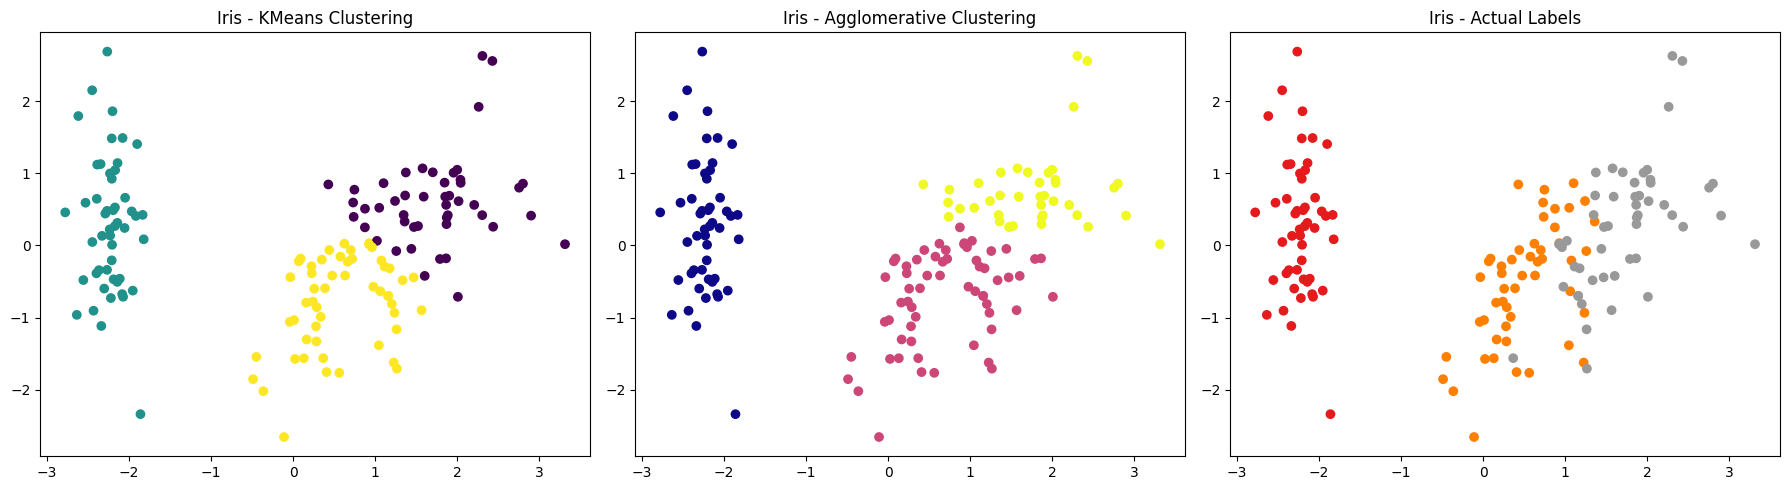

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X_pcaed[:, 0], X_pcaed[:, 1],
                c=labels_kmeans, cmap='viridis')
axes[0].set_title("Iris - KMeans Clustering")

axes[1].scatter(X_pcaed[:, 0], X_pcaed[:, 1],
                c=labels_agglo, cmap='plasma')
axes[1].set_title("Iris - Agglomerative Clustering")

axes[2].scatter(X_pcaed[:, 0], X_pcaed[:, 1],
                c=Y_numeric, cmap='Set1')
axes[2].set_title("Iris - Actual Labels")

plt.tight_layout()
plt.show()